<a href="https://colab.research.google.com/github/mudassir7328/Car-Price-Prediction/blob/main/cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
df = pd.read_csv("cars.csv")

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape: (8128, 13)

First 5 Rows:
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2  Individual       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3  Individual       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4  Individual       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                     torque  seats  
0            190

In [10]:
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None


In [11]:
print("Summary Statistics")
print(df.describe())

Summary Statistics
              year  selling_price     km_driven        seats
count  8128.000000   8.128000e+03  8.128000e+03  7907.000000
mean   2013.804011   6.382718e+05  6.981951e+04     5.416719
std       4.044249   8.062534e+05  5.655055e+04     0.959588
min    1983.000000   2.999900e+04  1.000000e+00     2.000000
25%    2011.000000   2.549990e+05  3.500000e+04     5.000000
50%    2015.000000   4.500000e+05  6.000000e+04     5.000000
75%    2017.000000   6.750000e+05  9.800000e+04     5.000000
max    2020.000000   1.000000e+07  2.360457e+06    14.000000


In [12]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate Rows:
1202


In [13]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats            208
dtype: int64


In [14]:
#Clean String Columns
# Example: "23.4 kmpl" → 23.4
def extract_number(val):
    try:
        return float(str(val).split()[0])
    except:
        return np.nan

df["mileage"]   = df["mileage"].apply(extract_number)
df["engine"]    = df["engine"].apply(extract_number)
df["max_power"] = df["max_power"].apply(extract_number)

df = df.drop(columns=["torque"])

df["mileage"]   = df["mileage"].fillna(df["mileage"].mean())
df["engine"]    = df["engine"].fillna(df["engine"].mean())
df["max_power"] = df["max_power"].fillna(df["max_power"].mean())
df["seats"]     = df["seats"].fillna(df["seats"].mean())

In [15]:
print("\nAfter Cleaning String Columns:")
print(df.head())



After Cleaning String Columns:
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage  engine  max_power  seats  
0  Individual       Manual   First Owner    23.40  1248.0      74.00    5.0  
1  Individual       Manual  Second Owner    21.14  1498.0     103.52    5.0  
2  Individual       Manual   Third Owner    17.70  1497.0      78.00    5.0  
3  Individual       Manual   First Owner    23.00  1396.0      90.00    5.0  
4  Individual       Manual   First Owner    16.10  1298.0      88.20    5.0  


In [16]:
print("\nAfter Filling - Missing Values:")
print(df.isnull().sum())


After Filling - Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64


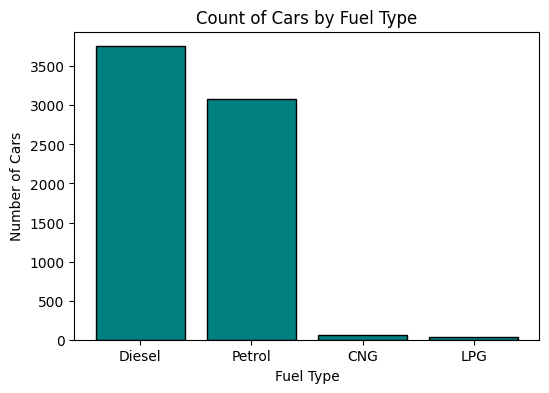


Insight:
The dataset contains far more Diesel and Petrol cars than CNG or LPG cars.


In [17]:
# GRAPH 1 : Count of Cars by Fuel Type
fuel_counts = df["fuel"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(fuel_counts.index, fuel_counts.values, color="teal", edgecolor="black")
plt.title("Count of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

print("\nInsight:")
print("The dataset contains far more Diesel and Petrol cars than CNG or LPG cars.")

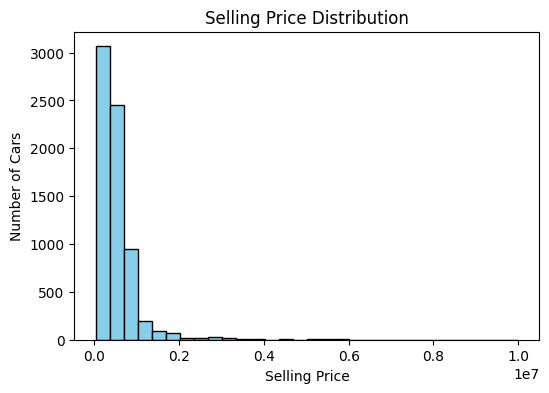


Insight:
Most cars are concentrated in the lower price range, while relatively few cars are priced very high.


In [18]:
# GRAPH 2 : Selling Price Distribution
plt.figure(figsize=(6, 4))
plt.hist(df["selling_price"], bins=30, color="skyblue", edgecolor="black")
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

print("\nInsight:")
print("Most cars are concentrated in the lower price range, while relatively few cars are priced very high.")


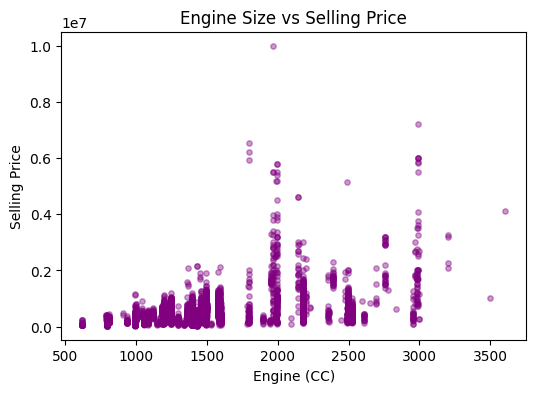


Insight:
Cars with larger engines generally tend to have higher selling prices, although the relationship is not perfectly linear.


In [19]:
# GRAPH 3 : Engine Size vs Selling Price
plt.figure(figsize=(6, 4))
plt.scatter(df["engine"], df["selling_price"], color="purple", alpha=0.4, s=15)
plt.xlabel("Engine (CC)")
plt.ylabel("Selling Price")
plt.title("Engine Size vs Selling Price")
plt.show()

print("\nInsight:")
print("Cars with larger engines generally tend to have higher selling prices, although the relationship is not perfectly linear.")


/tmp/ipykernel_4940/2891271968.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)


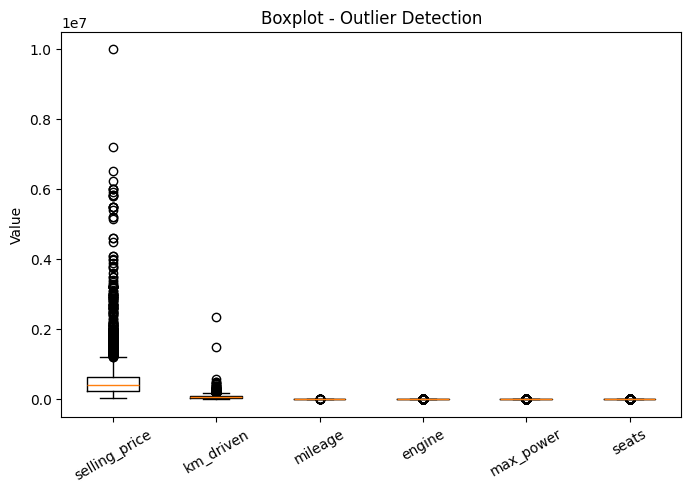

Insight:
  selling_price  : 328 outliers (values outside -325250.0 - 1208750.0)
  km_driven      : 167 outliers (values outside -50000.0 - 190000.0)
  mileage        : 23 outliers (values outside 8.9 - 30.4)
  engine         : 1207 outliers (values outside 745.5 - 1949.5)
  max_power      : 374 outliers (values outside 21.5 - 145.5)
  seats          : 1672 outliers (values outside 5.0 - 5.0)


In [20]:
# GRAPH 4 : Boxplot to Detect Outliers
outlier_cols = ["selling_price", "km_driven", "mileage", "engine", "max_power", "seats"]
plt.figure(figsize=(8, 5))
plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)
plt.title("Boxplot - Outlier Detection")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.show()

print("Insight:")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col:15s}: {outlier_count} outliers (values outside {round(lower,1)} - {round(upper,1)})")


In [21]:
# Remove Outliers using IQR method
print(f"\nShape before removing outliers: {df.shape}")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Shape after removing outliers: {df.shape}")



Shape before removing outliers: (6926, 12)
Shape after removing outliers: (4672, 12)


In [22]:
# Encode Categorical Columns
le = LabelEncoder()
cat_columns = ["fuel", "seller_type", "transmission", "owner", "name"]

print("\nEncoding Categorical Columns:")
for col in cat_columns:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col} → Encoded")

print("\nAfter Encoding:")
print(df.head())


Encoding Categorical Columns:
  fuel → Encoded
  seller_type → Encoded
  transmission → Encoded
  owner → Encoded
  name → Encoded

After Encoding:
   name  year  selling_price  km_driven  fuel  seller_type  transmission  \
0   745  2014         450000     145500     1            1             1   
1   977  2014         370000     120000     1            1             1   
2   240  2006         158000     140000     3            1             1   
3   528  2010         225000     127000     1            1             1   
4   786  2007         130000     120000     3            1             1   

   owner  mileage  engine  max_power  seats  
0      0    23.40  1248.0      74.00    5.0  
1      2    21.14  1498.0     103.52    5.0  
2      3    17.70  1497.0      78.00    5.0  
3      0    23.00  1396.0      90.00    5.0  
4      0    16.10  1298.0      88.20    5.0  


In [23]:
X = df.drop(columns=["selling_price"])   # Features
y = df["selling_price"]                  # Target

print("\nFeatures (X):")
print(X.columns.tolist())
print("\nTarget (y):", y.name)


Features (X):
['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']

Target (y): selling_price


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining Size : {X_train.shape}")
print(f"Testing  Size : {X_test.shape}")


Training Size : (3737, 11)
Testing  Size : (935, 11)


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nScaling Done!")


Scaling Done!


In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLinear Regression R2:", round(r2_score(y_test, lr_pred), 3))
print("Random Forest R2:", round(r2_score(y_test, y_pred), 3))


Linear Regression R2: 0.727
Random Forest R2: 0.893


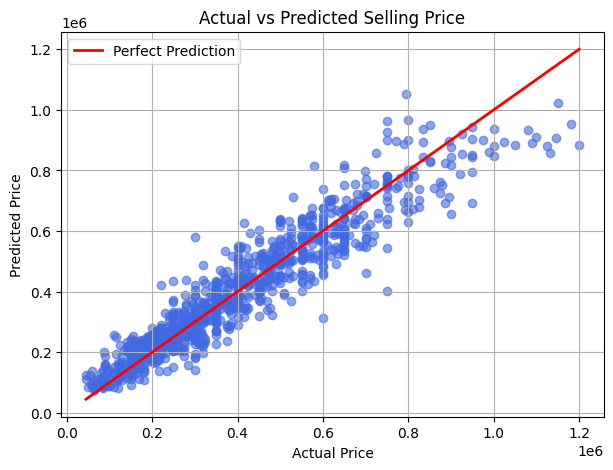

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred,
            color="royalblue",
            alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red",
         linewidth=2,
         label="Perfect Prediction")

plt.title("Actual vs Predicted Selling Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print("\nSample Predictions (first 10):")
print(y_pred[:10])




Sample Predictions (first 10):
[807599.86       740690.         160230.         419379.96
 965076.66666667 307239.96       172315.         615910.
 150049.98       273689.16666667]


In [30]:
comparison = pd.DataFrame({
    "Actual"    : y_test.iloc[:10].values,
    "Predicted" : np.round(y_pred[:10], 2),
    "Difference": [round(abs(a - p), 2)
                   for a, p in zip(y_test.iloc[:10], y_pred[:10])]
})

print("\nActual vs Predicted (first 10 rows):")
print(comparison.to_string(index=False))






Actual vs Predicted (first 10 rows):
 Actual  Predicted  Difference
 650000  807599.86   157599.86
 860000  740690.00   119310.00
 150000  160230.00    10230.00
 400000  419379.96    19379.96
 800000  965076.67   165076.67
 330000  307239.96    22760.04
 200000  172315.00    27685.00
 600000  615910.00    15910.00
 111000  150049.98    39049.98
 265000  273689.17     8689.17


In [31]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("----------MODEL PERFORMANCE STATS----------")
print(f"  MAE      : {round(mae, 2)}")
print(f"  MSE      : {round(mse, 2)}")
print(f"  RMSE     : {round(rmse, 2)}")
print(f"  R2 Score : {round(r2, 3)}")


----------MODEL PERFORMANCE STATS----------
  MAE      : 53806.25
  MSE      : 5310086197.26
  RMSE     : 72870.34
  R2 Score : 0.893


In [32]:
print("\n------- Predict Car Price -------")

try:
    name = float(input("Enter Car Name (encoded)      : "))
    year = float(input("Enter Year                    : "))
    km_driven = float(input("Enter KM Driven              : "))
    fuel = float(input("Enter Fuel (encoded)          : "))
    seller_type = float(input("Enter Seller Type (encoded)  : "))
    transmission = float(input("Enter Transmission (encoded) : "))
    owner = float(input("Enter Owner (encoded)         : "))
    mileage = float(input("Enter Mileage (kmpl)          : "))
    engine = float(input("Enter Engine CC              : "))
    max_power = float(input("Enter Max Power (bhp)        : "))
    seats = float(input("Enter Number of Seats        : "))

    user_input_df = pd.DataFrame([{
        "name": name,
        "year": year,
        "km_driven": km_driven,
        "fuel": fuel,
        "seller_type": seller_type,
        "transmission": transmission,
        "owner": owner,
        "mileage": mileage,
        "engine": engine,
        "max_power": max_power,
        "seats": seats
    }])

    user_input_scaled = scaler.transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]

    print("\n========================================")
    print(f"Predicted Car Price : ₹ {round(prediction, 2)}")
    print("========================================")

except Exception as e:
    print("An error occurred:", e)


------- Predict Car Price -------
Enter Car Name (encoded)      : 745  
Enter Year                    : 2014        
Enter KM Driven              : 145500     
Enter Fuel (encoded)          : 1            
Enter Seller Type (encoded)  : 1
Enter Transmission (encoded) : 1
Enter Owner (encoded)         : 0    
Enter Mileage (kmpl)          : 23.40  
Enter Engine CC              : 1248.0      
Enter Max Power (bhp)        : 74.00    
Enter Number of Seats        : 5.0

Predicted Car Price : ₹ 498249.97
